# __0.Workflow__

- (1) Dataset 확인
- (2) DataLoader
- (3) Model 정의
- (4) Loss 정의
- (5) Optimizer 정의
- (6) Training loop

# __1.Set enviornment__

- (1)가상환경 설치
    - conda create my_env
- (2)가상환경 활성화
    - conda activate my_env
- (3)가상환경 주피터 커널 등록
    - python -m ipykernel install my_env
- (3)필요 라이브러리 설치
    - python -m pip install my_package
    - `위 명령어로 설치하지 않으면, jupyter cell에서 기존 base에 깔린 모듈 인식. pip install ~ 사용 자제`


# __2.Data__

- data는 torchvision에서 제공하는 CIFAR10데이터를 이용하여 실습하자.
- torchvision : pytorch에서 제공하는 이미지 관련 라이브러리
    - 유명 데이터셋 제공 (CIFAR10, MNIST, ImageNet)
    - 이미지 변환(transform)
    - Pretrained 모델
- transforms : 이미지 전처리를 위한 모듈
    - Tensor 변환
    - 정규화
    - resize
    - random crop

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor()]) 
#이미지를 pytorch tensor로 변환하는 객체.

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

- trainset 은 torchvision의 dataset 객체를 저장한 것이다. 
    - (1)data
    - (2)targets
    - (3)classes
- trainset의 내부의 data구조를 알고싶다면,
`trainset.data`로 접근해야한다.

In [3]:
print(trainset.data.shape)

(50000, 32, 32, 3)


- trainset은 dataset의 객체이다. trainset의 이미지를 보기위해서는 Dataset객체에서 직접 하나 꺼내야한다.

Dataset의 `__getitem__` 메서드는 index 접근에 작동하고,

 반환값은 `(image, label)`의 튜플 형식이다.

In [ ]:
image, label = trainset[0]
print(image.shape)
print("[channel, height, width]")
print()


torch.Size([3, 32, 32])
[channel, height, width]


- torchvision에서 다운로드 받은 이미지를 하나 시각화 해보자.

    PyTorch의 dataset은 `(C, H, W)`의 형식으로 데이터를 제공한다.

    그러나 matplot은 `(H, W, C)`형식을 사용하여 차원을 바꿔주어야 한다.

In [5]:
import numpy as np 
img = image.numpy() #image tensor numpy로 반환
img = np.transpose(img, (1,2,0)) #index 1인 H를 맨앞으로, index 2인 W를 두번째로 ...

- trainset.calsses의 속성을 통해 해당 이미지 class도 알 수 있다.

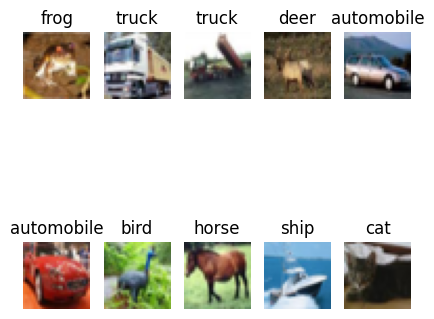

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize = (5,5))
#2행 5열짜리 액자 생성 = 10개
for i in range(10): #10개이미지에 들어갈 순서
    image, label = trainset[i]

    img = image.numpy()
    img = np.transpose(img, (1,2,0))

    ax = axes[i // 5, i % 5] #순서대로 삽입
    ax.imshow(img)
    ax.set_title(trainset.classes[label])
    ax.axis('off')
plt.show()

# __3.Model__

- pytorch에서는 nn.Module을 상속해서 모델을 생성한다.
    - `__init__` : layer 정의
    - `forward()` : 데이터 흐름 정의

- (1)nn.conv2d(in_channel, out_channel, kernel_size, padding)
    - nn.conv2d의 in_channel만 이미지에 따라 고정되고 나머지는 parameter이다.

- (2)nn.Linear(C * H * W, output)
    - nn.Linear에서는 마지막 pooling결과의 `C * H * W`를 직접 계산해주어야 한다.

- 크기 계산 공식
    - Conv: 
    `(H_out, W_out) = ({H_in - Kernel size + 2 * padding)/Stride} + 1`
    - maxpool:
    `h_out = {(h_in - k) / s} + 1`

__Convlayer2에서 channel이 16으로 바뀐것은, convlayer1에서 feature map이 16개의 kernel을 통과하여 16개가 생성되었기 때문이다.__


In [7]:
import torch #pytorch 기본
import torch.nn as nn #neural network layer 제공
import torch.nn.functional as F #activation 함수 제공

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, 3, padding = 1)
        #conv1 kernel 생성
        #input (3, 32, 32) -> output (16, 32, 32)
        self.pool = nn.MaxPool2d(2, 2)
        #polling kernel 생성
        #input (16, 32, 32) -> output (16, 16, 16)
        self.conv2 = nn.Conv2d(16, 32, 3, padding = 1)
        #conv2 kernel 생성
        #input (16, 16, 16) -> output (32, 16, 16)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        #fc weight 생성
        #input (32, 16, 16) -> flatten(2048, 128)
        self.fc2 = nn.Linear(128, 10)
        #input (2048, 128) -> (128, 10), class 10개이기때문.
    
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        #conv1 -> Relu -> Maxpool
        #(3, 32, 32) -> (16, 32, 32) -> (16, 16, 16)
        x = self.pool(F.relu(self.conv2(x)))
        #conv2 -> Relu -> MaxPool
        #(16, 16, 16) -> (32, 16, 16) -> (32, 8, 8)
        x = torch.flatten(x, 1)#1 은 batch 차원 제외
        #(batch, 32 * 8 * 8)
        x = F.relu(self.fc1(x))
        #(batch, 32 * 8 * 8) -> (2048, 128)
        x = self.fc2(x)
        #(2048, 128) -> (128, 10)
        return x

model = CNN()

# __4.Loss__

- 학습을 위한 loss를 계산하는 식을 작성하자.
    - cross entropy loss
    

In [8]:
loss_function = nn.CrossEntropyLoss()

# __5.Optimizer__

- optimizer는 파라미터를 최적화하는 과정에서 필요한것으로, gradient를 갱신하는 방식을 사용한다.
    - Adam 

`model.parameters()는 model의 학습가능한 모든 weight를 반환한다`

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

# __6.Training Loop__

- (1)optimizer 초기화
- (2)model_forward 계산
- (3)loss 계산
- (4)loss 역전파
- (5)optimizer 갱신


In [ ]:
from tqdm import tqdm
import time

epochs = 10
start = time.time()
for epoch in range(epochs):
    loop = tqdm(trainloader)
    for images, labels in loop:
        optimizer.zero_grad()#epoch마다 grad 초기화.
        outputs = model(images) #forward 자동 실행해준다.
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
        #description은 progress bar앞에 표시될 설명을 설정한다.
        loop.set_postfix(loss=loss.item())
        #set_postfix는 progress bar뒤에 표시될 정보를 추가한다.

    print("epoch:" , epoch, "loss:", loss.item())
end = time.time()
print("Training time: ", end - start)


Epoch [1/10]: 100%|██████████| 782/782 [00:12<00:00, 63.83it/s, loss=0.646]


epoch: 0 loss: 0.6458057165145874


Epoch [2/10]: 100%|██████████| 782/782 [00:11<00:00, 67.67it/s, loss=0.454]


epoch: 1 loss: 0.45398086309432983


Epoch [3/10]: 100%|██████████| 782/782 [00:11<00:00, 65.72it/s, loss=0.199] 


...

epoch: 7 loss: 0.01808222010731697


Epoch [9/10]: 100%|██████████| 782/782 [00:13<00:00, 58.28it/s, loss=0.252] 


epoch: 8 loss: 0.2521038055419922


Epoch [10/10]: 100%|██████████| 782/782 [00:11<00:00, 66.70it/s, loss=1.07]  

epoch: 9 loss: 1.0735740661621094
Training time:  -121.54101777076721


# __7.Usage GPU__

- pytorch를 실행할때 기본적으로 CPU 사용이 default이다. 따라서 위의 학습 시간이 121초로 2분정도 걸린것을 확인할 수있다. `따라서 gpu사용이 가능하다면 gpu, mps사용이 가능하다면 mps를 사용하자` (+)이때, gpu는 cuda로 실행한다.

- (1)Device 설정

In [14]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

- (2)Model Gpu이동

In [17]:
model_MPS = CNN().to(device)

In [18]:
optimizer_2 = torch.optim.Adam(model_MPS.parameters())
loss_function_2 = nn.CrossEntropyLoss()

- (3)training loop에서 tensor이동

In [21]:
epochs = 10
start = time.time()
for epoch in range(epochs):
    loop = tqdm(trainloader)
    for images, labels in loop:
        #images, labels를 device로 옴겨야한다.
        images = images.to(device) 
        labels = labels.to(device)
        optimizer_2.zero_grad()
        outputs = model_MPS(images)
        loss = loss_function_2(outputs, labels)
        loss.backward()
        optimizer_2.step()
        loop.set_description(f"Epochs:{epoch+1}/{epochs}")
        loop.set_postfix(loss = loss.item())
    print("epoch: ", epoch, "loss: ", loss.item())
end = time.time()
print("Training time: ", end - start)

Epochs:1/10: 100%|██████████| 782/782 [00:07<00:00, 111.33it/s, loss=1.3]  


epoch:  0 loss:  1.2992792129516602


Epochs:2/10: 100%|██████████| 782/782 [00:07<00:00, 111.09it/s, loss=1.09] 


epoch:  1 loss:  1.0881121158599854


Epochs:3/10: 100%|██████████| 782/782 [00:07<00:00, 111.15it/s, loss=0.742]


...

epoch:  7 loss:  0.7439204454421997


Epochs:9/10: 100%|██████████| 782/782 [00:06<00:00, 111.72it/s, loss=1.07] 


epoch:  8 loss:  1.0678315162658691


Epochs:10/10: 100%|██████████| 782/782 [00:07<00:00, 109.76it/s, loss=0.823]

epoch:  9 loss:  0.8228816986083984
Training time:  70.4792377948761
